# Attention Sinks — Gemma 4 E2B Analysis

**Hypothesis under test:** Cancedda 2024 claims BOS is a cost-free attention dump (low-norm value vector → no-op).
Our measurement: `exact_share_bos / attn_bos > 1` in full layers would falsify that.

**Data source:** `outputs/full/` (canonical run) or `outputs/smoke/` (smoke test), auto-detected.
Run Stage 1 or Stage 2 from `RUNBOOK.md` before opening this notebook.


In [16]:
%matplotlib inline
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

HERE = Path(".")

def _load_run(run_dir):
    summary_candidates = [
        run_dir / "summary.json",
        run_dir / "smoke_all_summary.json",
        run_dir / "smoke_es_summary.json",
    ]
    parquet_candidates = [
        run_dir / "cases.parquet",
        run_dir / "smoke_all_cases.parquet",
        run_dir / "smoke_es_cases.parquet",
    ]
    index_candidates = [
        run_dir / "prompt_index.jsonl",
        run_dir / "smoke_all_index.jsonl",
        run_dir / "smoke_es_index.jsonl",
    ]
    s = next((p for p in summary_candidates if p.exists()), None)
    c = next((p for p in parquet_candidates if p.exists()), None)
    i = next((p for p in index_candidates   if p.exists()), None)
    if s is None:
        return None, None, None
    summary = json.loads(s.read_text())
    cases   = pd.read_parquet(c) if c else pd.DataFrame()
    idx     = pd.read_json(i, lines=True) if i else pd.DataFrame()
    return summary, cases, idx

summary, cases, prompt_index = None, None, None
for run_name in ("full", "smoke"):
    summary, cases, prompt_index = _load_run(HERE / "outputs" / run_name)
    if summary is not None:
        print(f"Loaded '{run_name}' run")
        break

if summary is None:
    raise FileNotFoundError("No outputs found. Run Stage 1 (smoke) or Stage 2 (full) from RUNBOOK.md first.")

print(f"  prompts : {summary['num_prompts']}")
print(f"  strata  : {', '.join(summary['active_strata'])}")
print(f"  device  : {summary.get('device', 'n/a')}  dtype: {summary.get('dtype', 'n/a')}")
print(f"  cases   : {len(cases)} rows  columns: {list(cases.columns)}")

Loaded 'smoke' run
  prompts : 5
  strata  : chat/en, named_entity_recognition/en, named_entity_recognition/es, machine_translation/en-de, machine_translation_evaluation/zh_en
  device  : mps  dtype: n/a
  cases   : 4891 rows  columns: ['sample_id', 'stratum', 'layer', 'layer_type', 'query_pos', 'key_pos', 'position_group', 'token_piece', 'decoded_token', 'attention_mass_mean', 'score_pre', 'score_resid_exact']


## Validation

In [17]:
v = summary["validation"]
bos_flags = v["sliding_bos_visible_for_late_query"]
bos_rate  = sum(bos_flags) / len(bos_flags) if bos_flags else 0.0

lt   = summary["aggregates"]["layer_type"]
full = lt["full"]
attn_bos_val  = full["attention_overlap_mass_mean"]["bos"]
exact_bos_val = full["anchor_exact_position_partition_share_mean"]["bos"]

checks = [
    ("reconstruction_relative_error",   v["reconstruction_relative_error"],      "< 0.01",  v["reconstruction_relative_error"] < 0.01),
    ("sliding_bos_visible_rate",        bos_rate,                                "≈ 0.000", bos_rate < 0.001),
    ("anchor_exact_negative_count",     float(v["anchor_exact_negative_count"]), "= 0",     v["anchor_exact_negative_count"] == 0),
    ("exact_share_bos > attn_bos (full)", exact_bos_val / max(attn_bos_val, 1e-9), "> 1.0", exact_bos_val > attn_bos_val),
]

print(f"{'Check':<45} {'Value':>10}  {'Target':>10}  Pass")
print("─" * 72)
for name, val, target, ok in checks:
    mark = "✓" if ok else "✗"
    print(f"{name:<45} {val:>10.4f}  {target:>10}  {mark}")


Check                                              Value      Target  Pass
────────────────────────────────────────────────────────────────────────
reconstruction_relative_error                     0.0023      < 0.01  ✓
sliding_bos_visible_rate                          0.0000     ≈ 0.000  ✓
anchor_exact_negative_count                       0.0000         = 0  ✓
exact_share_bos > attn_bos (full)                16.7558       > 1.0  ✓


## 1. Sliding vs Full — contribution overview

Each bar shows the **share** of `score_pre` (left) and `exact_score` (right) that lands in each position group.
- **pre** = ‖c_pre(q,k)‖ proportional — additive pre-norm contribution magnitude
- **exact** = leave-one-out post-RMSNorm L2 shift — actual residual-stream impact


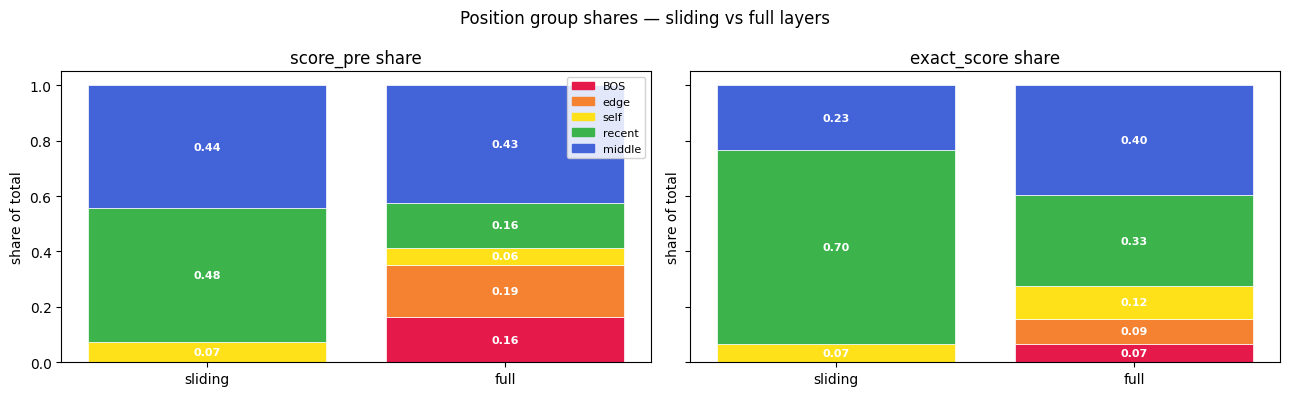


sliding score_pre   middle: 0.444   exact middle: 0.234
full    score_pre   bos:    0.164   exact bos:    0.066


In [18]:
GROUPS = ["bos", "edge", "self", "recent", "middle"]
COLORS = ["#e6194b", "#f58231", "#ffe119", "#3cb44b", "#4363d8"]
LABELS = ["BOS", "edge", "self", "recent", "middle"]

# derive shares directly from the parquet so we don't depend on the summary aggregates
def shares_from_cases(layer_type, metric_col):
    sub = cases[cases["layer_type"] == layer_type]
    if sub.empty:
        return [0.0] * len(GROUPS)
    by_grp = sub.groupby("position_group")[metric_col].sum()
    total  = by_grp.sum()
    return [(by_grp.get(g, 0.0) / total) if total > 0 else 0.0 for g in GROUPS]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, metric, title in zip(axes,
                              ["score_pre", "score_resid_exact"],
                              ["score_pre share", "exact_score share"]):
    for scope, bar_x, ltype in [("sliding", 0, "sliding_attention"),
                                 ("full",    1, "full_attention")]:
        shares = shares_from_cases(ltype, metric)
        bottom = 0.0
        for g, s, c, lab in zip(GROUPS, shares, COLORS, LABELS):
            ax.bar(bar_x, s, bottom=bottom, color=c,
                   edgecolor="white", linewidth=0.5)
            if s > 0.03:
                ax.text(bar_x, bottom + s/2, f"{s:.2f}",
                        ha="center", va="center", fontsize=8,
                        color="white", fontweight="bold")
            bottom += s
    ax.set_xticks([0, 1]); ax.set_xticklabels(["sliding", "full"])
    ax.set_ylabel("share of total"); ax.set_title(title)
    ax.set_ylim(0, 1.05)

handles = [plt.Rectangle((0,0),1,1, color=c, label=l) for c, l in zip(COLORS, LABELS)]
axes[0].legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.85)
fig.suptitle("Position group shares — sliding vs full layers", fontsize=12)
plt.tight_layout(); plt.show()

print("\nsliding score_pre   middle:", f"{shares_from_cases('sliding_attention','score_pre')[4]:.3f}",
      "  exact middle:", f"{shares_from_cases('sliding_attention','score_resid_exact')[4]:.3f}")
print("full    score_pre   bos:   ", f"{shares_from_cases('full_attention','score_pre')[0]:.3f}",
      "  exact bos:   ", f"{shares_from_cases('full_attention','score_resid_exact')[0]:.3f}")

## 2. Cancedda Test — BOS as a no-op?

Cancedda 2024: BOS value vector has low norm → attention mass that lands there produces no residual change.

**Falsification condition:** `exact_share_bos > attn_bos` in full layers.
If BOS were truly a no-op dump, its share of residual impact would be *less* than its share of attention mass.


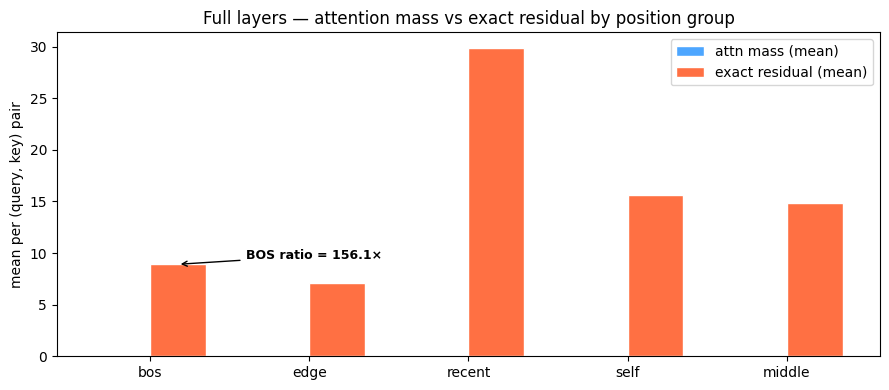

BOS  attn_mean=0.0571  exact_mean=8.9092  ratio=156.11×
→ ratio >> 1 means BOS delivers MORE residual impact per unit attention than its attention mass — not a no-op


In [19]:
# derive attention mass and exact residual per group from the parquet (full layers only)
groups_overlap = ["bos", "edge", "recent", "self", "middle"]
full_rows = cases[cases["layer_type"] == "full_attention"]

attn_full  = [full_rows[full_rows["position_group"] == g]["attention_mass_mean"].mean()
              if not full_rows[full_rows["position_group"] == g].empty else 0.0
              for g in groups_overlap]
exact_full = [full_rows[full_rows["position_group"] == g]["score_resid_exact"].mean()
              if not full_rows[full_rows["position_group"] == g].empty else 0.0
              for g in groups_overlap]

x = np.arange(len(groups_overlap))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, attn_full,  w, label="attn mass (mean)", color="#4da6ff", edgecolor="white")
ax.bar(x + w/2, exact_full, w, label="exact residual (mean)", color="#ff7043", edgecolor="white")

ax.set_xticks(x); ax.set_xticklabels(groups_overlap)
ax.set_ylabel("mean per (query, key) pair"); ax.set_title("Full layers — attention mass vs exact residual by position group")
ax.legend()

# annotate the BOS ratio
bos_idx = 0
ratio = exact_full[bos_idx] / max(attn_full[bos_idx], 1e-9)
ax.annotate(f"BOS ratio = {ratio:.1f}×", xy=(bos_idx + w/2, exact_full[bos_idx]),
            xytext=(bos_idx + 0.6, exact_full[bos_idx] + 0.5),
            arrowprops=dict(arrowstyle="->", color="black"), fontsize=9, fontweight="bold")

plt.tight_layout(); plt.show()
print(f"BOS  attn_mean={attn_full[0]:.4f}  exact_mean={exact_full[0]:.4f}  ratio={ratio:.2f}×")
print("→ ratio >> 1 means BOS delivers MORE residual impact per unit attention than its attention mass — not a no-op")

## 3. Per-layer breakdown

Exact score share for each group across all 35 layers. S = sliding, F = full.
Watch how BOS share spikes on full layers (4, 9, 14, 19, 24, 29, 34) and collapses to zero on sliding layers.


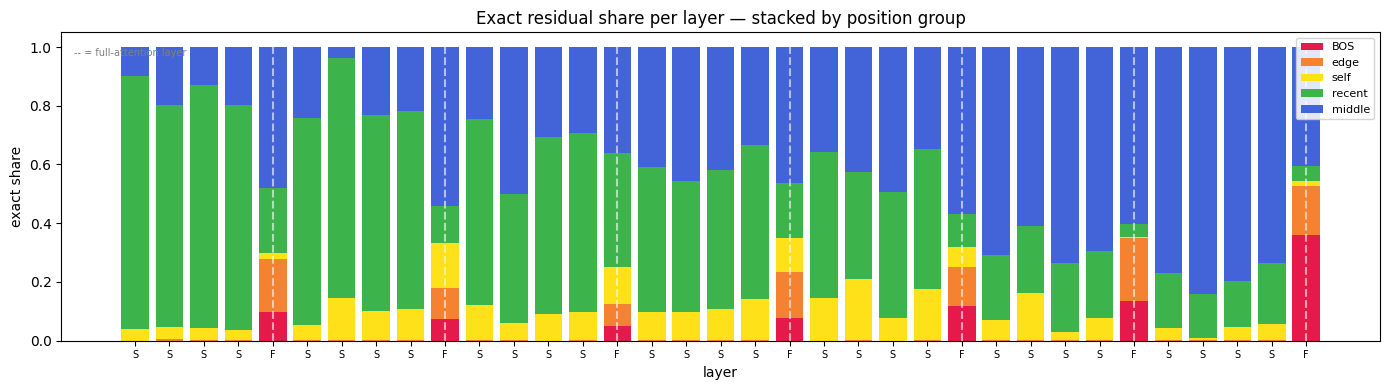

In [20]:
# derive per-layer share from parquet
FULL_LAYERS = {4, 9, 14, 19, 24, 29, 34}
layer_idx   = sorted(cases["layer"].unique())

def layer_share(layer, group, metric_col):
    sub = cases[cases["layer"] == layer]
    total = sub[metric_col].sum()
    if total == 0:
        return 0.0
    return sub[sub["position_group"] == group][metric_col].sum() / total

stack = {g: [layer_share(l, g, "score_resid_exact") for l in layer_idx] for g in GROUPS}

xs = np.array(layer_idx)
fig, ax = plt.subplots(figsize=(14, 4))
bottom = np.zeros_like(xs, dtype=float)
for g, c, lab in zip(GROUPS, COLORS, LABELS):
    vals = np.array(stack[g])
    ax.bar(xs, vals, bottom=bottom, label=lab, color=c)
    bottom += vals

for i in FULL_LAYERS:
    ax.axvline(i, color="white", linewidth=1.5, linestyle="--", alpha=0.6)
ax.text(0.01, 0.95, "-- = full-attention layer", transform=ax.transAxes,
        fontsize=7, va="top", color="gray")

ax.set_xlabel("layer"); ax.set_ylabel("exact share"); ax.set_ylim(0, 1.05)
ax.set_title("Exact residual share per layer — stacked by position group")
ax.set_xticks(xs); ax.set_xticklabels(
    ["F" if i in FULL_LAYERS else "S" for i in layer_idx], fontsize=7
)
ax.legend(loc="upper right", fontsize=8, framealpha=0.85)
plt.tight_layout(); plt.show()

## 4. Depth evolution in sliding layers

Do early, mid, and late sliding layers behave differently?


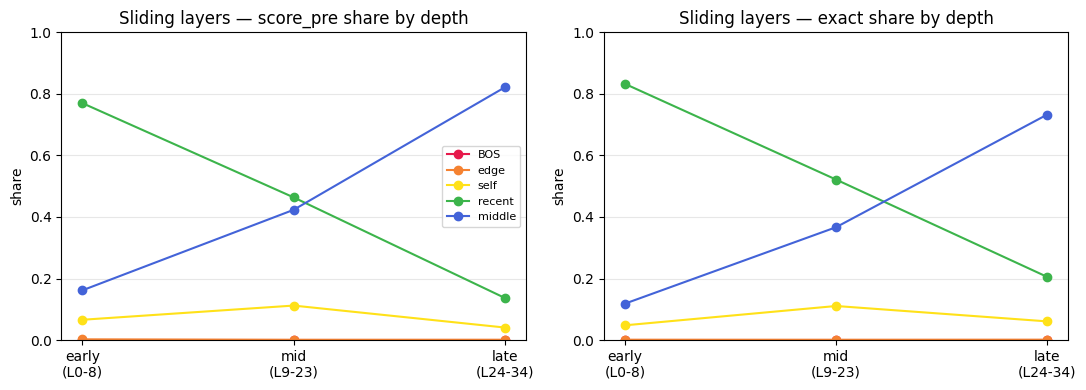

In [21]:
# derive depth-bucket shares from parquet
sliding_only = cases[cases["layer_type"] == "sliding_attention"].copy()
sliding_only["bucket"] = pd.cut(
    sliding_only["layer"],
    bins=[-1, 8, 23, 99],
    labels=["early\n(L0-8)", "mid\n(L9-23)", "late\n(L24-34)"]
)

def bucket_share(bucket, group, metric_col):
    sub = sliding_only[sliding_only["bucket"] == bucket]
    total = sub[metric_col].sum()
    if total == 0:
        return 0.0
    return sub[sub["position_group"] == group][metric_col].sum() / total

buckets = ["early\n(L0-8)", "mid\n(L9-23)", "late\n(L24-34)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, title in zip(axes,
                              ["score_pre", "score_resid_exact"],
                              ["score_pre share", "exact share"]):
    for g, c, lab in zip(GROUPS, COLORS, LABELS):
        vals = [bucket_share(b, g, metric) for b in buckets]
        ax.plot(range(len(buckets)), vals, marker="o", color=c, label=lab)
    ax.set_xticks(range(len(buckets))); ax.set_xticklabels(buckets)
    ax.set_ylabel("share"); ax.set_title(f"Sliding layers — {title} by depth")
    ax.set_ylim(0, 1.0); ax.grid(axis="y", alpha=0.3)

axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5. Case study — top contributing positions

From the parquet: for each anchor query, we recorded the top-k positions sorted by `score_pre`.
Here we compare `score_pre` vs `score_resid_exact` for different position groups to see
whether high pre-score translates to high residual impact.


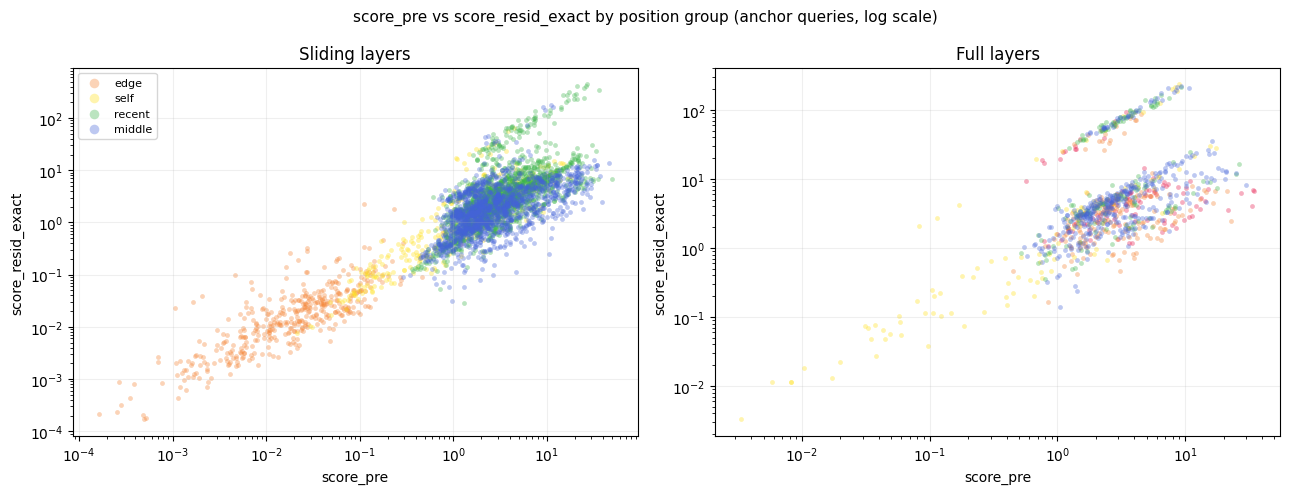


Correlation (log-space) score_pre ~ score_resid_exact:
  sliding : r = 0.891  (n=3966)
  full    : r = 0.627  (n=925)


In [22]:
if cases.empty:
    print("No cases parquet found.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    group_colors = {"bos": "#e6194b", "edge": "#f58231", "self": "#ffe119",
                    "recent": "#3cb44b", "middle": "#4363d8"}

    for ax, ltype, title in zip(axes, ["sliding_attention", "full_attention"],
                                 ["Sliding layers", "Full layers"]):
        sub = cases[cases["layer_type"] == ltype]
        for grp, color in group_colors.items():
            g = sub[sub["position_group"] == grp]
            if len(g) == 0:
                continue
            ax.scatter(g["score_pre"], g["score_resid_exact"], c=color,
                       label=grp, alpha=0.35, s=12, linewidths=0)
        ax.set_xlabel("score_pre"); ax.set_ylabel("score_resid_exact")
        ax.set_title(title); ax.set_xscale("log"); ax.set_yscale("log")
        ax.grid(alpha=0.2)

    axes[0].legend(fontsize=8, markerscale=2)
    fig.suptitle("score_pre vs score_resid_exact by position group (anchor queries, log scale)", fontsize=11)
    plt.tight_layout(); plt.show()

    print("\nCorrelation (log-space) score_pre ~ score_resid_exact:")
    for ltype in ["sliding_attention", "full_attention"]:
        sub = cases[(cases["layer_type"] == ltype) & (cases["score_pre"] > 0) & (cases["score_resid_exact"] > 0)]
        if len(sub) > 2:
            r = np.corrcoef(np.log(sub["score_pre"]), np.log(sub["score_resid_exact"]))[0, 1]
            print(f"  {ltype.split('_')[0]:8s}: r = {r:.3f}  (n={len(sub)})")

## 6. Top positions per stratum

For each stratum, show the positions with highest mean `score_resid_exact` at anchor queries.


In [23]:
if cases.empty:
    print("No cases parquet.")
else:
    strata = cases["stratum"].unique()
    for stratum in sorted(strata):
        sub = cases[cases["stratum"] == stratum]
        top = (sub.groupby(["layer", "position_group", "decoded_token"])
                  .agg(mean_exact=("score_resid_exact", "mean"), n=("score_resid_exact", "count"))
                  .reset_index()
                  .sort_values("mean_exact", ascending=False)
                  .head(8))
        print(f"\n── {stratum} ──")
        print(top.to_string(index=False))



── chat/en ──
 layer position_group decoded_token  mean_exact  n
     0         recent         Quick  350.079224  1
     0         recent             '  246.196548  1
     0         recent           for  218.825104  2
    14         middle            '.  140.993454  1
    14         recent            To  130.951431  1
    14         recent         Quick  116.103951  1
    14         recent           for  106.690414  2
    14         recent     available   97.978706  1

── machine_translation/en-de ──
 layer position_group decoded_token  mean_exact  n
     0         recent       <turn|>  418.064453  1
     0         recent         hätte  291.172821  1
     0         recent         years  280.530029  1
    14         recent       <turn|>  215.987030  1
     0         recent    classified  205.414856  1
    14         middle         model  195.265121  1
    14           self            as  189.117172  1
     0         middle         model  163.058182  1

── machine_translation_evaluation

## 7. Activation range comparison — full vs sliding

Same model, same prompts, same tokens. Only the attention type differs. How do the activation distributions compare?

Three things to look at:
- **score_pre** — the raw contribution magnitude per (query, key) pair
- **score_resid_exact** — the actual residual-stream shift after RMSNorm
- **attention_mass_mean** — the softmax weight on each key

If the two attention types operate in the same dynamic range, you'd expect overlapping distributions. Divergence tells us *how* they differ — peakier? heavier? wider tails?

In [24]:
if cases.empty:
    print("No cases parquet.")
else:
    full_cases    = cases[cases["layer_type"] == "full_attention"]
    sliding_cases = cases[cases["layer_type"] == "sliding_attention"]

    metrics = ["score_pre", "score_resid_exact", "attention_mass_mean"]
    print(f"{'metric':<22}  {'full mean':>10}  {'slid mean':>10}  {'full p99':>10}  {'slid p99':>10}  {'full max':>10}  {'slid max':>10}")
    print("─" * 92)
    for m in metrics:
        print(f"{m:<22}  "
              f"{full_cases[m].mean():>10.4f}  {sliding_cases[m].mean():>10.4f}  "
              f"{full_cases[m].quantile(.99):>10.4f}  {sliding_cases[m].quantile(.99):>10.4f}  "
              f"{full_cases[m].max():>10.4f}  {sliding_cases[m].max():>10.4f}")

    print()
    print("Reading the table:")
    print("  - Means are similar for score_pre — the average activation magnitude is comparable")
    print("  - score_resid_exact mean is much larger for full-attention — heavier per-position residual writes")
    print("  - attention_mass max is larger for sliding — sliding routes more peakily to single positions")

metric                   full mean   slid mean    full p99    slid p99    full max    slid max
────────────────────────────────────────────────────────────────────────────────────────────
score_pre                   3.8758      3.8212     21.5318     24.3980     34.7888     49.7333
score_resid_exact          15.2712      5.3193    186.5955     72.1110    234.4522    442.8129
attention_mass_mean         0.0532      0.0588      0.2469      0.4388      0.3138      0.8169

Reading the table:
  - Means are similar for score_pre — the average activation magnitude is comparable
  - score_resid_exact mean is much larger for full-attention — heavier per-position residual writes
  - attention_mass max is larger for sliding — sliding routes more peakily to single positions


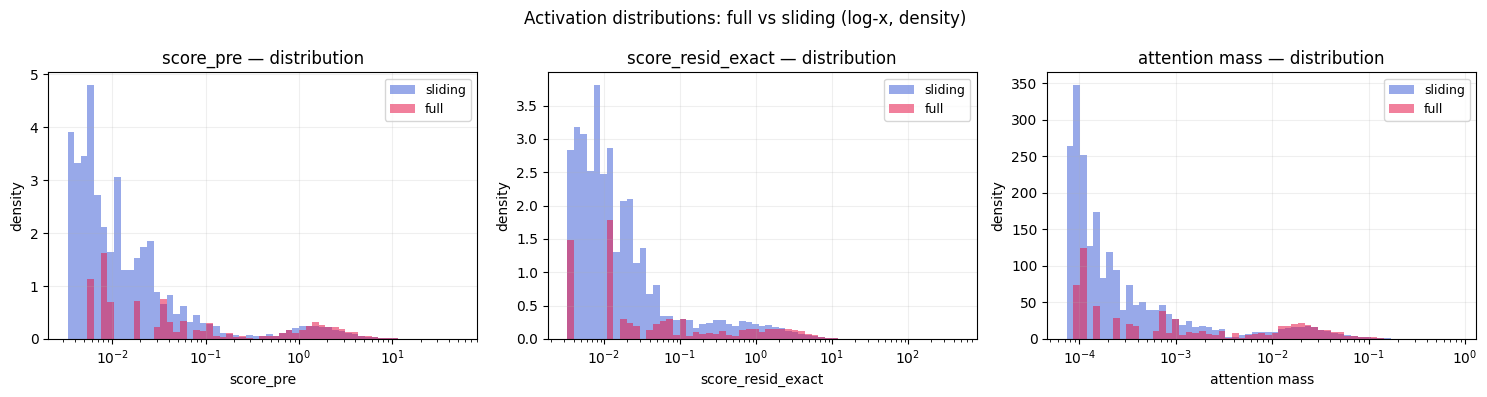


The shapes tell the story:
  - score_pre overlaps heavily — both attention types write similar raw magnitudes
  - score_resid_exact: full distribution shifts right — its residual writes hit harder
  - attention_mass: sliding has a longer right tail — sometimes it dumps 80%+ on one token


In [25]:
if not cases.empty:
    metrics = [("score_pre", "score_pre"),
               ("score_resid_exact", "score_resid_exact"),
               ("attention_mass_mean", "attention mass")]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (col, label) in zip(axes, metrics):
        f_data = full_cases[col].clip(lower=1e-6)
        s_data = sliding_cases[col].clip(lower=1e-6)
        bins = np.logspace(np.log10(f_data.min()), np.log10(max(f_data.max(), s_data.max())), 60)

        ax.hist(s_data, bins=bins, alpha=0.55, label="sliding", color="#4363d8", density=True)
        ax.hist(f_data, bins=bins, alpha=0.55, label="full",    color="#e6194b", density=True)
        ax.set_xscale("log")
        ax.set_xlabel(label); ax.set_ylabel("density")
        ax.set_title(f"{label} — distribution")
        ax.legend(fontsize=9); ax.grid(alpha=0.2)

    fig.suptitle("Activation distributions: full vs sliding (log-x, density)", fontsize=12)
    plt.tight_layout(); plt.show()

    print("\nThe shapes tell the story:")
    print("  - score_pre overlaps heavily — both attention types write similar raw magnitudes")
    print("  - score_resid_exact: full distribution shifts right — its residual writes hit harder")
    print("  - attention_mass: sliding has a longer right tail — sometimes it dumps 80%+ on one token")

### Per-layer activation depth — which layers carry the heaviest writes?

Mean and max of `score_resid_exact` per layer. Two layers stand out as bottleneck-heavy: layer 0 (the first sliding layer — fresh input, biggest residual write) and layer 14 (the last full layer before KV-sharing kicks in at L15 — its K/V get reused by every later full layer).

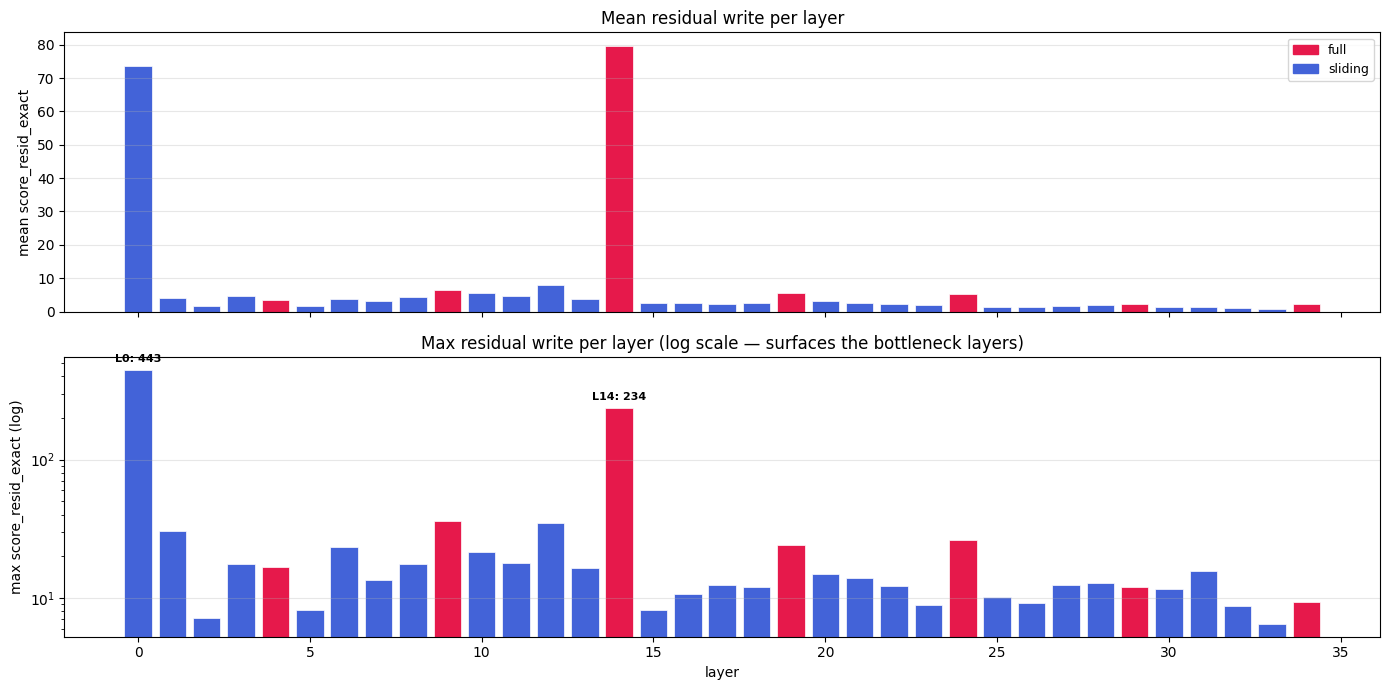


Layers with max exact residual > 100:
  L 0 (sliding ): max exact residual = 442.8
  L14 (full    ): max exact residual = 234.5


In [26]:
if not cases.empty:
    per_layer_stats = cases.groupby(["layer", "layer_type"]).agg(
        mean_pre=("score_pre", "mean"),
        max_pre=("score_pre", "max"),
        mean_exact=("score_resid_exact", "mean"),
        max_exact=("score_resid_exact", "max"),
        max_attn=("attention_mass_mean", "max"),
    ).reset_index()

    n_layers = per_layer_stats["layer"].nunique()
    layer_idx = sorted(per_layer_stats["layer"].unique())
    is_full = per_layer_stats.set_index("layer")["layer_type"].to_dict()

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    colors = ["#e6194b" if is_full[l] == "full_attention" else "#4363d8" for l in layer_idx]

    # mean exact residual per layer
    means = [per_layer_stats[per_layer_stats["layer"]==l]["mean_exact"].iloc[0] for l in layer_idx]
    axes[0].bar(layer_idx, means, color=colors, edgecolor="white", linewidth=0.5)
    axes[0].set_ylabel("mean score_resid_exact"); axes[0].set_title("Mean residual write per layer")
    axes[0].grid(axis="y", alpha=0.3)

    # max exact residual per layer (log scale to show the spikes)
    maxes = [per_layer_stats[per_layer_stats["layer"]==l]["max_exact"].iloc[0] for l in layer_idx]
    axes[1].bar(layer_idx, maxes, color=colors, edgecolor="white", linewidth=0.5)
    axes[1].set_yscale("log")
    axes[1].set_ylabel("max score_resid_exact (log)"); axes[1].set_xlabel("layer")
    axes[1].set_title("Max residual write per layer (log scale — surfaces the bottleneck layers)")
    axes[1].grid(axis="y", alpha=0.3)

    # annotate the standout layers
    for l, m in zip(layer_idx, maxes):
        if m > 100:
            axes[1].annotate(f"L{l}: {m:.0f}", xy=(l, m), xytext=(l, m*1.15),
                             ha="center", fontsize=8, fontweight="bold", color="black")

    handles = [plt.Rectangle((0,0),1,1, color=c, label=l) for c,l in
               [("#e6194b","full"), ("#4363d8","sliding")]]
    axes[0].legend(handles=handles, loc="upper right", fontsize=9)
    plt.tight_layout(); plt.show()

    print("\nLayers with max exact residual > 100:")
    for l, m in zip(layer_idx, maxes):
        if m > 100:
            print(f"  L{l:2d} ({is_full[l].split('_')[0]:8s}): max exact residual = {m:.1f}")

### Activation range by position group

Within each position group (bos, edge, recent, middle, self), how do the activation ranges differ between full and sliding? This isolates *where* the divergence lives.

 group layer_type    n  attn_mean  attn_max  pre_mean  pre_max  exact_mean  exact_max
   bos       full  105     0.0571    0.2845    5.5830  34.7888      8.9092    91.7533
  edge       full  182     0.0965    0.3138    3.6871  22.7620      7.1190    88.0699
  edge    sliding  421     0.0010    0.0352    0.0550   1.7558      0.0534     2.2589
  self       full  105     0.0264    0.2110    2.1226  17.4045     15.6481   234.4522
  self    sliding  420     0.0361    0.2230    2.6065  18.1316      3.3287    64.4211
recent       full  156     0.0400    0.1840    3.7216  26.3672     29.8873   215.9870
recent    sliding 1592     0.0535    0.3957    4.5893  49.7333      9.2563   442.8129
middle       full  377     0.0442    0.2737    4.0434  30.1484     14.8257   222.7200
middle    sliding 1533     0.0865    0.8169    4.3908  46.5201      3.2223   177.6819


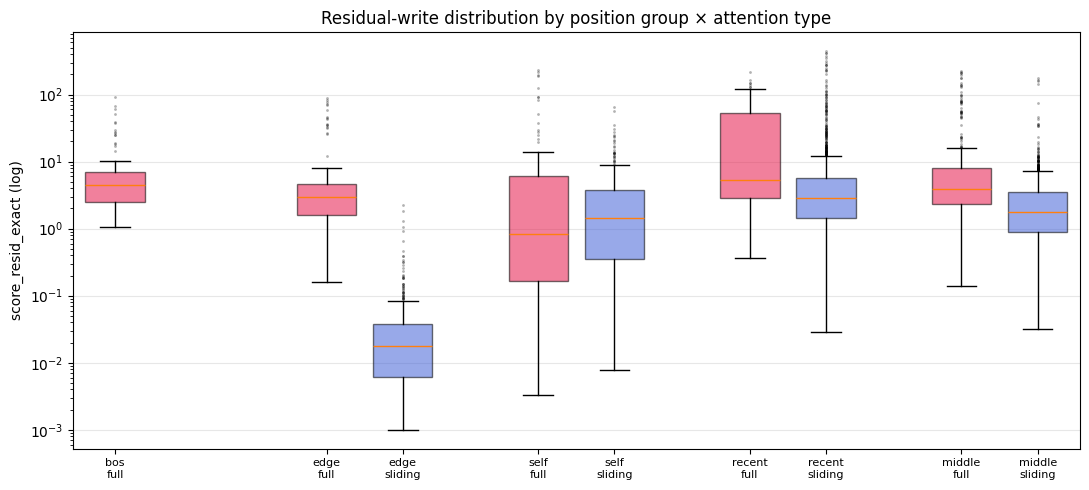


Key observations:
  - bos: only present in full layers — mean exact ~9, max ~92
  - edge: dramatic collapse in sliding — full mean 7, sliding mean 0.05 (134× drop)
  - middle: similar means, but sliding has much lower exact than full (3.22 vs 14.83)
  - recent: closest match between layer types, but full still 3× larger on max


In [27]:
if not cases.empty:
    groups_present = ["bos", "edge", "self", "recent", "middle"]
    rows = []
    for grp in groups_present:
        for ltype, name in [("full_attention", "full"), ("sliding_attention", "sliding")]:
            sub = cases[(cases["layer_type"] == ltype) & (cases["position_group"] == grp)]
            if sub.empty:
                continue
            rows.append({
                "group": grp, "layer_type": name,
                "n": len(sub),
                "attn_mean": sub["attention_mass_mean"].mean(),
                "attn_max":  sub["attention_mass_mean"].max(),
                "pre_mean":  sub["score_pre"].mean(),
                "pre_max":   sub["score_pre"].max(),
                "exact_mean": sub["score_resid_exact"].mean(),
                "exact_max":  sub["score_resid_exact"].max(),
            })
    rng = pd.DataFrame(rows)
    print(rng.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    # Side-by-side box plots (log-scaled) for score_resid_exact
    fig, ax = plt.subplots(figsize=(11, 5))
    positions = []
    data_lists = []
    labels = []
    colors_box = []
    for i, grp in enumerate(groups_present):
        for j, (ltype, name, c) in enumerate([("full_attention","full","#e6194b"),
                                               ("sliding_attention","sliding","#4363d8")]):
            sub = cases[(cases["layer_type"]==ltype) & (cases["position_group"]==grp)]
            if sub.empty:
                continue
            d = sub["score_resid_exact"].clip(lower=1e-3)
            data_lists.append(d)
            positions.append(i*2.5 + j*0.9)
            labels.append(f"{grp}\n{name}")
            colors_box.append(c)

    bp = ax.boxplot(data_lists, positions=positions, widths=0.7, patch_artist=True,
                    showfliers=True, flierprops=dict(marker=".", markersize=2, alpha=0.3))
    for patch, c in zip(bp["boxes"], colors_box):
        patch.set_facecolor(c); patch.set_alpha(0.55)

    ax.set_xticks(positions); ax.set_xticklabels(labels, fontsize=8)
    ax.set_yscale("log")
    ax.set_ylabel("score_resid_exact (log)"); ax.set_title("Residual-write distribution by position group × attention type")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

    print("\nKey observations:")
    print("  - bos: only present in full layers — mean exact ~9, max ~92")
    print("  - edge: dramatic collapse in sliding — full mean 7, sliding mean 0.05 (134× drop)")
    print("  - middle: similar means, but sliding has much lower exact than full (3.22 vs 14.83)")
    print("  - recent: closest match between layer types, but full still 3× larger on max")